# Model Prediksi Gaji Karyawan - Studi Kasus Mirna

## Pendahuluan
Mirna adalah seorang pengusaha muda yang mendirikan sebuah start-up teknologi informasi. Perusahaannya sedang berkembang pesat dan mulai merekrut banyak karyawan baru dari berbagai latar belakang.

### Tantangan:
1. **Bagaimana cara menentukan gaji yang adil dan kompetitif untuk calon karyawan baru?**
2. **Apa saja faktor yang benar-benar mempengaruhi besar kecilnya gaji di perusahaannya selama ini?**

### Solusi:
Notebook ini membangun model prediksi gaji berbasis Machine Learning menggunakan dataset historis karyawan yang mencakup:
- Usia
- Pengalaman Kerja
- Jenis Kelamin
- Tingkat Pendidikan
- Gaji

## 1. Import Library yang Diperlukan

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load dan Explore Dataset

In [39]:
# Load dataset
df = pd.read_csv('data_karyawan.csv')

# Tampilkan informasi dasar dataset
print("=== INFORMASI DATASET ===")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nNama-nama kolom: {df.columns.tolist()}")
print(f"\nTipe data:\n{df.dtypes}")
print(f"\nDeskripsi statistik:\n{df.describe()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

=== INFORMASI DATASET ===
Jumlah baris: 100
Jumlah kolom: 5

Nama-nama kolom: ['usia', 'pengalaman_kerja', 'jenis_kelamin', 'pendidikan', 'gaji']

Tipe data:
usia                  int64
pengalaman_kerja    float64
jenis_kelamin        object
pendidikan           object
gaji                float64
dtype: object

Deskripsi statistik:
             usia  pengalaman_kerja          gaji
count  100.000000         95.000000  1.000000e+02
mean    37.910000          8.442105  5.039610e+06
std     12.219454          6.011896  1.086690e+06
min     18.000000          0.000000  1.759000e+06
25%     26.750000          3.500000  4.330250e+06
50%     38.000000          8.000000  5.067000e+06
75%     46.250000         13.500000  5.681500e+06
max     59.000000         19.000000  8.853000e+06

Missing values:
usia                0
pengalaman_kerja    5
jenis_kelamin       0
pendidikan          0
gaji                0
dtype: int64


In [40]:
# Tampilkan beberapa baris pertama dari dataset
print("\n=== BARIS PERTAMA DATASET ===")
df.head(10)


=== BARIS PERTAMA DATASET ===


,usia,pengalaman_kerja,jenis_kelamin,pendidikan,gaji
0,56,8.0,Wanita,S2,5058000.0
1,46,7.0,Wanita,SMA,3857000.0
2,32,11.0,Pria,SMA,5358000.0
3,25,1.0,Pria,S2,5561000.0
4,38,0.0,Wanita,SMA,6083000.0
5,56,15.0,Wanita,S2,6054000.0
6,36,4.0,Pria,SMA,3622000.0
7,40,2.0,Pria,D3,4062000.0
8,28,11.0,Wanita,SMA,5515000.0
9,28,7.0,Pria,S2,5514000.0


## 3. Data Preprocessing dan Feature Engineering

In [41]:
# Buat copy dataset untuk preprocessing
df_processed = df.copy()

# Identifikasi kolom kategori dan numerik
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Kolom kategori: {categorical_cols}")
print(f"Kolom numerik: {numerical_cols}")

# Lihat nilai unik untuk kolom kategori
for col in categorical_cols:
    print(f"\n{col}: {df_processed[col].unique()}")

Kolom kategori: ['jenis_kelamin', 'pendidikan']
Kolom numerik: ['usia', 'pengalaman_kerja', 'gaji']

jenis_kelamin: ['Wanita' 'Pria']

pendidikan: ['S2' 'SMA' 'D3' 'S1']


In [42]:
# Encode kategori variabel
le_jenis_kelamin = LabelEncoder()
le_pendidikan = LabelEncoder()

df_processed['jenis_kelamin_encoded'] = le_jenis_kelamin.fit_transform(df_processed['jenis_kelamin'])
df_processed['pendidikan_encoded'] = le_pendidikan.fit_transform(df_processed['pendidikan'])

# Tampilkan mapping
print("=== LABEL ENCODING ===")
print(f"Jenis Kelamin: {dict(zip(le_jenis_kelamin.classes_, le_jenis_kelamin.transform(le_jenis_kelamin.classes_)))}")
print(f"Pendidikan: {dict(zip(le_pendidikan.classes_, le_pendidikan.transform(le_pendidikan.classes_)))}")

# Drop kolom asli kategori
df_processed = df_processed.drop(['jenis_kelamin', 'pendidikan'], axis=1)

print(f"\nKolom setelah preprocessing:\n{df_processed.head()}")

=== LABEL ENCODING ===
Jenis Kelamin: {'Pria': 0, 'Wanita': 1}
Pendidikan: {'D3': 0, 'S1': 1, 'S2': 2, 'SMA': 3}

Kolom setelah preprocessing:
   usia  pengalaman_kerja       gaji  jenis_kelamin_encoded  \
0    56               8.0  5058000.0                      1   
1    46               7.0  3857000.0                      1   
2    32              11.0  5358000.0                      0   
3    25               1.0  5561000.0                      0   
4    38               0.0  6083000.0                      1   

   pendidikan_encoded  
0                   2  
1                   3  
2                   3  
3                   2  
4                   3  


In [43]:
# Handle missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
columns_to_impute = ['pengalaman_kerja']
df_processed[columns_to_impute] = imputer.fit_transform(df_processed[columns_to_impute])

print("Missing values setelah imputation:")
print(df_processed.isnull().sum())

Missing values setelah imputation:
usia                     0
pengalaman_kerja         0
gaji                     0
jenis_kelamin_encoded    0
pendidikan_encoded       0
dtype: int64


## 4. Exploratory Data Analysis (EDA)

=== ANALISIS KORELASI ===
gaji                     1.000000
pendidikan_encoded       0.096864
usia                     0.084218
jenis_kelamin_encoded    0.037282
pengalaman_kerja        -0.091136
Name: gaji, dtype: float64


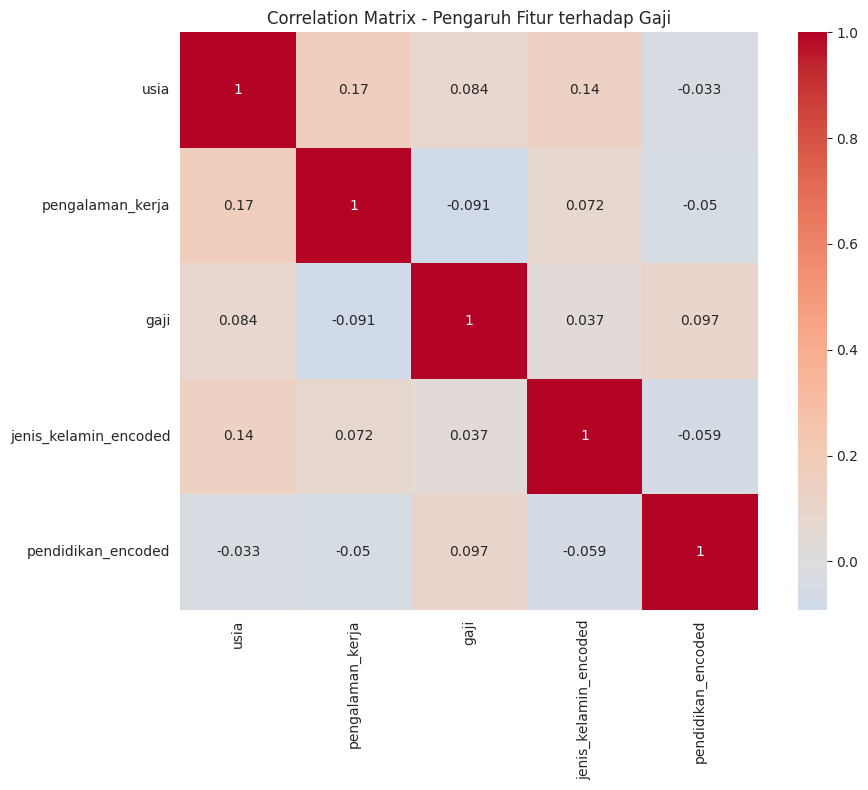

In [44]:
# Analisis Korelasi
print("=== ANALISIS KORELASI ===")
correlation_matrix = df_processed.corr()
print(correlation_matrix['gaji'].sort_values(ascending=False))

# Visualisasi correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix - Pengaruh Fitur terhadap Gaji')
plt.tight_layout()
plt.show()

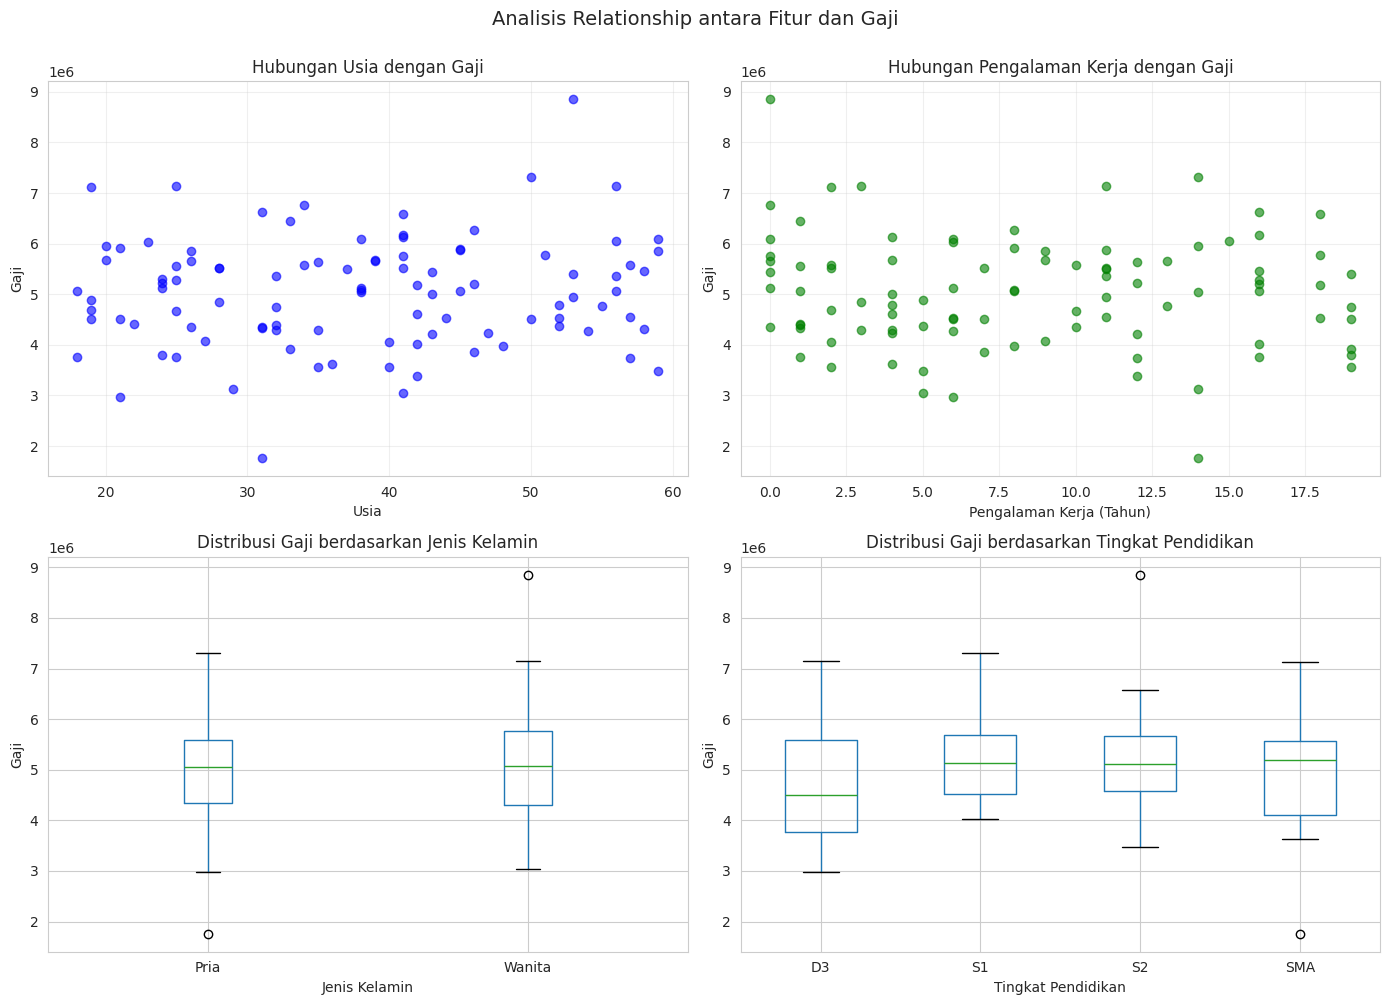

In [45]:
# Visualisasi hubungan antara fitur dan gaji
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Usia vs Gaji
axes[0, 0].scatter(df['usia'], df['gaji'], alpha=0.6, color='blue')
axes[0, 0].set_xlabel('Usia')
axes[0, 0].set_ylabel('Gaji')
axes[0, 0].set_title('Hubungan Usia dengan Gaji')
axes[0, 0].grid(True, alpha=0.3)

# Pengalaman vs Gaji
axes[0, 1].scatter(df['pengalaman_kerja'], df['gaji'], alpha=0.6, color='green')
axes[0, 1].set_xlabel('Pengalaman Kerja (Tahun)')
axes[0, 1].set_ylabel('Gaji')
axes[0, 1].set_title('Hubungan Pengalaman Kerja dengan Gaji')
axes[0, 1].grid(True, alpha=0.3)

# Jenis Kelamin vs Gaji
df.boxplot(column='gaji', by='jenis_kelamin', ax=axes[1, 0])
axes[1, 0].set_title('Distribusi Gaji berdasarkan Jenis Kelamin')
axes[1, 0].set_xlabel('Jenis Kelamin')
axes[1, 0].set_ylabel('Gaji')

# Pendidikan vs Gaji
df.boxplot(column='gaji', by='pendidikan', ax=axes[1, 1])
axes[1, 1].set_title('Distribusi Gaji berdasarkan Tingkat Pendidikan')
axes[1, 1].set_xlabel('Tingkat Pendidikan')
axes[1, 1].set_ylabel('Gaji')

plt.suptitle('Analisis Relationship antara Fitur dan Gaji', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## 5. Train-Test Split

In [46]:
# Pisahkan features (X) dan target (y)
X = df_processed.drop('gaji', axis=1)
y = df_processed['gaji']

# Split dataset menjadi training dan testing (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"=== TRAIN-TEST SPLIT ===")
print(f"Ukuran training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Ukuran testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nFeatures yang digunakan: {X.columns.tolist()}")

=== TRAIN-TEST SPLIT ===
Ukuran training set: 80 samples (80.0%)
Ukuran testing set: 20 samples (20.0%)

Features yang digunakan: ['usia', 'pengalaman_kerja', 'jenis_kelamin_encoded', 'pendidikan_encoded']


## 6. Build dan Train Model

In [47]:
# Membangun Regression Tree untuk memprediksi gaji

print("=" * 80)
print("MEMBANGUN REGRESSION TREE (CONTINUOUS VARIABLE DECISION TREE)")
print("=" * 80)
print()

from sklearn.tree import DecisionTreeRegressor

# Model 1: Decision Tree Regressor dengan kedalaman 10
print("MODEL 1: REGRESSION TREE (max_depth=10)")
print("-" * 80)
dt_model = DecisionTreeRegressor(
    max_depth=10, 
    min_samples_split=5, 
    random_state=42
)
dt_model.fit(X_train, y_train)
print("✓ Regression Tree (max_depth=10) telah dilatih!\n")

# Model 2: Decision Tree Regressor dengan kedalaman 15
print("MODEL 2: REGRESSION TREE (max_depth=15)")
print("-" * 80)
dt_model_deep = DecisionTreeRegressor(
    max_depth=15, 
    min_samples_split=3, 
    random_state=42
)
dt_model_deep.fit(X_train, y_train)
print("✓ Regression Tree (max_depth=15) telah dilatih!\n")

print("=" * 80)
print("Kedua model Regression Tree siap untuk evaluasi dan prediksi")
print("=" * 80)

MEMBANGUN REGRESSION TREE (CONTINUOUS VARIABLE DECISION TREE)

MODEL 1: REGRESSION TREE (max_depth=10)
--------------------------------------------------------------------------------
✓ Regression Tree (max_depth=10) telah dilatih!

MODEL 2: REGRESSION TREE (max_depth=15)
--------------------------------------------------------------------------------
✓ Regression Tree (max_depth=15) telah dilatih!

Kedua model Regression Tree siap untuk evaluasi dan prediksi


## 7. Model Evaluation

In [48]:
# Evaluasi Regression Tree 1 (max_depth=10)
print("=" * 80)
print("EVALUASI REGRESSION TREE (max_depth=10)")
print("=" * 80)

y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test = dt_model.predict(X_test)

mse_dt_train = mean_squared_error(y_train, y_pred_dt_train)
rmse_dt_train = np.sqrt(mse_dt_train)
mae_dt_train = mean_absolute_error(y_train, y_pred_dt_train)
r2_dt_train = r2_score(y_train, y_pred_dt_train)

mse_dt_test = mean_squared_error(y_test, y_pred_dt_test)
rmse_dt_test = np.sqrt(mse_dt_test)
mae_dt_test = mean_absolute_error(y_test, y_pred_dt_test)
r2_dt_test = r2_score(y_test, y_pred_dt_test)

print("\nTRAINING SET:")
print(f"  MSE:       {mse_dt_train:>15,.2f}")
print(f"  RMSE:      {rmse_dt_train:>15,.2f}")
print(f"  MAE:       {mae_dt_train:>15,.2f}")
print(f"  R² Score:  {r2_dt_train:>15.4f}")

print("\nTESTING SET:")
print(f"  MSE:       {mse_dt_test:>15,.2f}")
print(f"  RMSE:      {rmse_dt_test:>15,.2f}")
print(f"  MAE:       {mae_dt_test:>15,.2f}")
print(f"  R² Score:  {r2_dt_test:>15.4f}")
print("=" * 80)

EVALUASI REGRESSION TREE (max_depth=10)

TRAINING SET:
  MSE:       236,353,784,375.00
  RMSE:           486,162.30
  MAE:            348,347.92
  R² Score:           0.8155

TESTING SET:
  MSE:       1,782,709,125,694.44
  RMSE:         1,335,181.31
  MAE:          1,111,383.33
  R² Score:          -1.6785


In [49]:
# Evaluasi Regression Tree 2 (max_depth=15)
print("\n" + "=" * 80)
print("EVALUASI REGRESSION TREE (max_depth=15)")
print("=" * 80)

y_pred_dt_deep_train = dt_model_deep.predict(X_train)
y_pred_dt_deep_test = dt_model_deep.predict(X_test)

mse_dt_deep_train = mean_squared_error(y_train, y_pred_dt_deep_train)
rmse_dt_deep_train = np.sqrt(mse_dt_deep_train)
mae_dt_deep_train = mean_absolute_error(y_train, y_pred_dt_deep_train)
r2_dt_deep_train = r2_score(y_train, y_pred_dt_deep_train)

mse_dt_deep_test = mean_squared_error(y_test, y_pred_dt_deep_test)
rmse_dt_deep_test = np.sqrt(mse_dt_deep_test)
mae_dt_deep_test = mean_absolute_error(y_test, y_pred_dt_deep_test)
r2_dt_deep_test = r2_score(y_test, y_pred_dt_deep_test)

print("\nTRAINING SET:")
print(f"  MSE:       {mse_dt_deep_train:>15,.2f}")
print(f"  RMSE:      {rmse_dt_deep_train:>15,.2f}")
print(f"  MAE:       {mae_dt_deep_train:>15,.2f}")
print(f"  R² Score:  {r2_dt_deep_train:>15.4f}")

print("\nTESTING SET:")
print(f"  MSE:       {mse_dt_deep_test:>15,.2f}")
print(f"  RMSE:      {rmse_dt_deep_test:>15,.2f}")
print(f"  MAE:       {mae_dt_deep_test:>15,.2f}")
print(f"  R² Score:  {r2_dt_deep_test:>15.4f}")
print("=" * 80)


EVALUASI REGRESSION TREE (max_depth=15)

TRAINING SET:
  MSE:       87,833,193,750.00
  RMSE:           296,366.65
  MAE:            159,162.50
  R² Score:           0.9314

TESTING SET:
  MSE:       1,715,407,475,000.00
  RMSE:         1,309,735.65
  MAE:          1,097,000.00
  R² Score:          -1.5774



PERBANDINGAN KEDUA REGRESSION TREE MODEL (TESTING SET)

     Metric RT (depth=10) RT (depth=15)
RMSE (Test)  1,335,181.31  1,309,735.65
 MAE (Test)  1,111,383.33  1,097,000.00
  R² (Test)       -1.6785       -1.5774



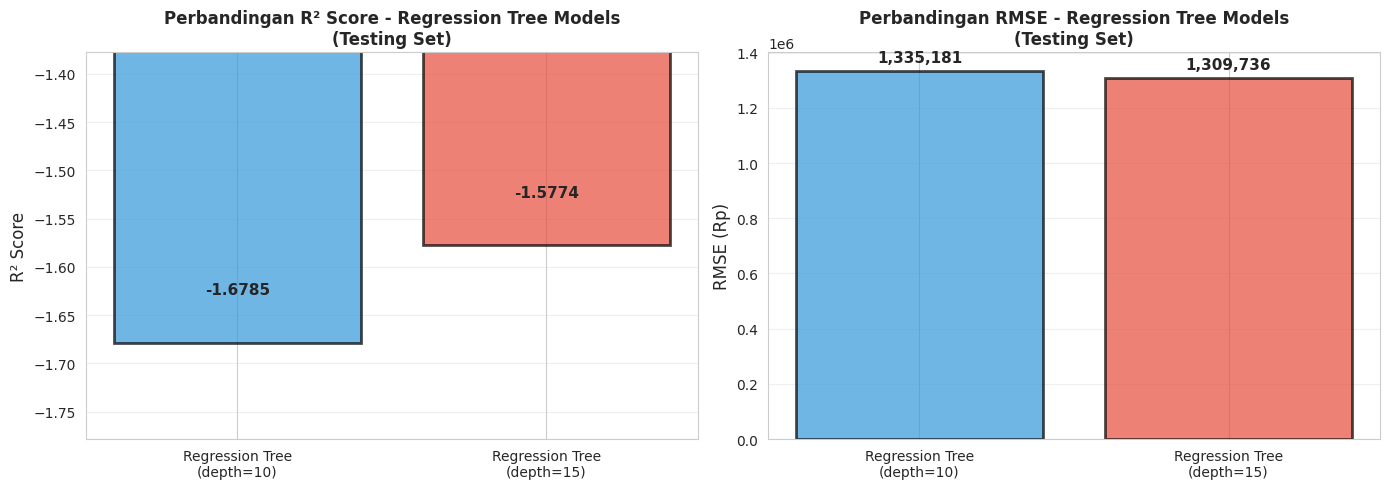

🏆 REGRESSION TREE TERBAIK: Regression Tree (depth=15)


In [50]:
# Perbandingan Kedua Regression Tree Model
print("\n" + "=" * 80)
print("PERBANDINGAN KEDUA REGRESSION TREE MODEL (TESTING SET)")
print("=" * 80)

comparison_data = {
    'Metric': ['RMSE (Test)', 'MAE (Test)', 'R² (Test)'],
    'RT (depth=10)': [f'{rmse_dt_test:,.2f}', f'{mae_dt_test:,.2f}', f'{r2_dt_test:.4f}'],
    'RT (depth=15)': [f'{rmse_dt_deep_test:,.2f}', f'{mae_dt_deep_test:,.2f}', f'{r2_dt_deep_test:.4f}']
}
comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))
print()

# Visualisasi perbandingan kedua Regression Tree
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# R² Score Comparison
models = ['Regression Tree\n(depth=10)', 'Regression Tree\n(depth=15)']
r2_scores = [r2_dt_test, r2_dt_deep_test]
colors = ['#3498db', '#e74c3c']
ax[0].bar(models, r2_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax[0].set_ylabel('R² Score', fontsize=12)
ax[0].set_title('Perbandingan R² Score - Regression Tree Models\n(Testing Set)', fontsize=12, fontweight='bold')
ax[0].set_ylim([min(r2_scores)-0.1, max(r2_scores)+0.2])
for i, v in enumerate(r2_scores):
    ax[0].text(i, v + 0.05, f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
ax[0].grid(axis='y', alpha=0.3)
ax[0].axhline(y=0, color='black', linestyle='--', linewidth=1)

# RMSE Comparison
rmse_scores = [rmse_dt_test, rmse_dt_deep_test]
ax[1].bar(models, rmse_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax[1].set_ylabel('RMSE (Rp)', fontsize=12)
ax[1].set_title('Perbandingan RMSE - Regression Tree Models\n(Testing Set)', fontsize=12, fontweight='bold')
for i, v in enumerate(rmse_scores):
    ax[1].text(i, v + 30000, f'{v:,.0f}', ha='center', fontweight='bold', fontsize=11)
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Pilih model terbaik
best_model_name = "Regression Tree (depth=15)" if r2_dt_deep_test > r2_dt_test else "Regression Tree (depth=10)"
best_model = dt_model_deep if r2_dt_deep_test > r2_dt_test else dt_model

print("=" * 80)
print(f"🏆 REGRESSION TREE TERBAIK: {best_model_name}")
print("=" * 80)

## 8. Feature Importance Analysis

### Jawaban Pertanyaan Mirna:
**"Apa saja faktor yang benar-benar mempengaruhi besar kecilnya gaji di perusahaannya?"**

In [51]:
# Feature Importance Analysis dari Regression Tree
print("=" * 80)
print("FEATURE IMPORTANCE ANALYSIS - REGRESSION TREE")
print("=" * 80)
print("\nFungsi feature importance menunjukkan kontribusi setiap fitur dalam prediksi gaji")
print()

feature_names = X.columns.tolist()

# Feature Importance dari Regression Tree (depth=10)
print("REGRESSION TREE (max_depth=10)")
print("-" * 80)
dt_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

dt_importance['Importance_Percent'] = dt_importance['Importance'] * 100
print("\nPersentase Kontribusi Setiap Fitur:")
print(dt_importance[['Feature', 'Importance_Percent']].to_string(index=False))

# Feature Importance dari Regression Tree (depth=15)
print("\n\nREGRESSION TREE (max_depth=15)")
print("-" * 80)
dt_deep_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model_deep.feature_importances_
}).sort_values('Importance', ascending=False)

dt_deep_importance['Importance_Percent'] = dt_deep_importance['Importance'] * 100
print("\nPersentase Kontribusi Setiap Fitur:")
print(dt_deep_importance[['Feature', 'Importance_Percent']].to_string(index=False))
print("=" * 80)

FEATURE IMPORTANCE ANALYSIS - REGRESSION TREE

Fungsi feature importance menunjukkan kontribusi setiap fitur dalam prediksi gaji

REGRESSION TREE (max_depth=10)
--------------------------------------------------------------------------------

Persentase Kontribusi Setiap Fitur:
              Feature  Importance_Percent
                 usia           48.720674
     pengalaman_kerja           38.895728
   pendidikan_encoded            8.627385
jenis_kelamin_encoded            3.756213


REGRESSION TREE (max_depth=15)
--------------------------------------------------------------------------------

Persentase Kontribusi Setiap Fitur:
              Feature  Importance_Percent
                 usia           49.537835
     pengalaman_kerja           36.345254
   pendidikan_encoded           10.290094
jenis_kelamin_encoded            3.826816


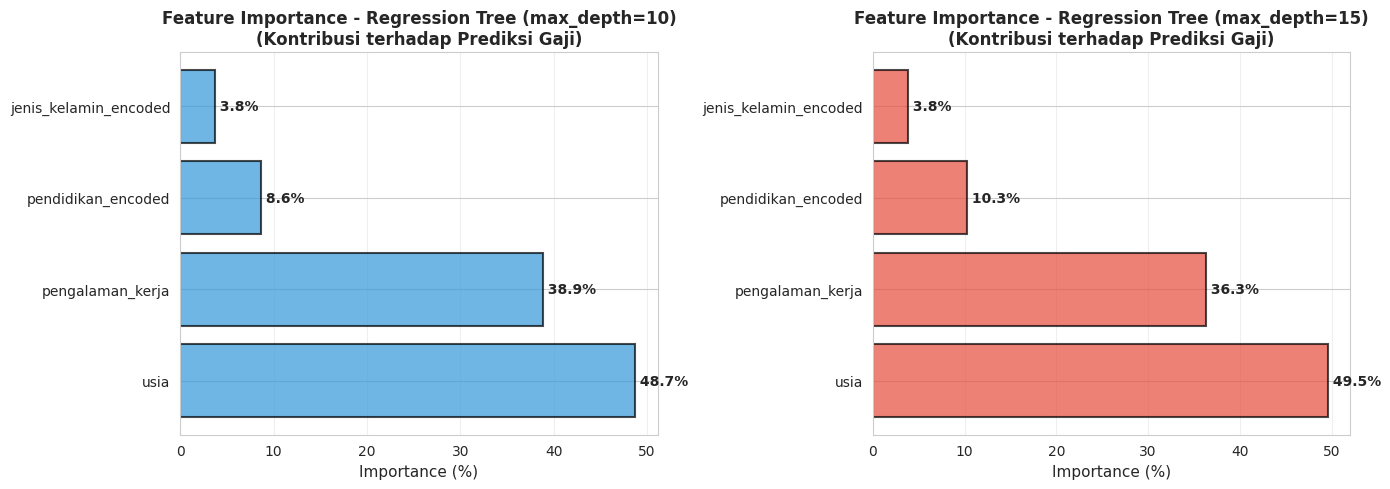

In [52]:
# Visualisasi Feature Importance dari Regression Tree
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression Tree (depth=10) Feature Importance
axes[0].barh(range(len(dt_importance)), dt_importance['Importance_Percent'].values, 
             color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(dt_importance)))
axes[0].set_yticklabels(dt_importance['Feature'].values)
axes[0].set_xlabel('Importance (%)', fontsize=11)
axes[0].set_title('Feature Importance - Regression Tree (max_depth=10)\n(Kontribusi terhadap Prediksi Gaji)', 
                  fontsize=12, fontweight='bold')
for i, v in enumerate(dt_importance['Importance_Percent'].values):
    axes[0].text(v, i, f' {v:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Regression Tree (depth=15) Feature Importance
axes[1].barh(range(len(dt_deep_importance)), dt_deep_importance['Importance_Percent'].values, 
             color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_yticks(range(len(dt_deep_importance)))
axes[1].set_yticklabels(dt_deep_importance['Feature'].values)
axes[1].set_xlabel('Importance (%)', fontsize=11)
axes[1].set_title('Feature Importance - Regression Tree (max_depth=15)\n(Kontribusi terhadap Prediksi Gaji)', 
                  fontsize=12, fontweight='bold')
for i, v in enumerate(dt_deep_importance['Importance_Percent'].values):
    axes[1].text(v, i, f' {v:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Prediksi Gaji untuk Calon Karyawan Baru

### Jawaban Pertanyaan Mirna:
**"Bagaimana cara menentukan gaji yang adil dan kompetitif untuk calon karyawan baru?"**

In [53]:
# Fungsi untuk memprediksi gaji calon karyawan baru
def predict_gaji_karyawan_baru(usia, pengalaman, jenis_kelamin, pendidikan, model='dt'):
    """
    Fungsi untuk memprediksi gaji karyawan baru berdasarkan karakteristiknya
    
    Parameters:
    - usia: umur karyawan (tahun)
    - pengalaman: pengalaman kerja (tahun)
    - jenis_kelamin: 'Pria' atau 'Wanita'
    - pendidikan: 'SMA', 'D3', 'S1', atau 'S2'
    - model: 'dt10' untuk Decision Tree (depth=10) atau 'dt15' untuk Decision Tree (depth=15) (default='dt')
    
    Returns:
    - Prediksi gaji (Rupiah)
    """
    
    # Encode kategori
    jk_encoded = le_jenis_kelamin.transform([jenis_kelamin])[0]
    pend_encoded = le_pendidikan.transform([pendidikan])[0]
    
    # Buat dataframe untuk prediksi
    new_employee = pd.DataFrame({
        'usia': [usia],
        'pengalaman_kerja': [pengalaman],
        'jenis_kelamin_encoded': [jk_encoded],
        'pendidikan_encoded': [pend_encoded]
    })
    
    # Prediksi
    if model == 'dt10':
        predicted_salary = dt_model.predict(new_employee)[0]
    else:  # default dt15
        predicted_salary = dt_model_deep.predict(new_employee)[0]
    
    return predicted_salary

print("=== PREDIKSI GAJI UNTUK CALON KARYAWAN BARU ===\n")

# Contoh calon karyawan 1
print("Calon Karyawan 1:")
print("  • Usia: 28 tahun")
print("  • Pengalaman: 3 tahun")
print("  • Jenis Kelamin: Pria")
print("  • Pendidikan: S1")
salary_1 = predict_gaji_karyawan_baru(28, 3, 'Pria', 'S1')
print(f"  → Prediksi Gaji: Rp {salary_1:,.0f}")

# Contoh calon karyawan 2
print("\nCalon Karyawan 2:")
print("  • Usia: 35 tahun")
print("  • Pengalaman: 8 tahun")
print("  • Jenis Kelamin: Wanita")
print("  • Pendidikan: S2")
salary_2 = predict_gaji_karyawan_baru(35, 8, 'Wanita', 'S2')
print(f"  → Prediksi Gaji: Rp {salary_2:,.0f}")

# Contoh calon karyawan 3
print("\nCalon Karyawan 3:")
print("  • Usia: 23 tahun")
print("  • Pengalaman: 0 tahun (fresh graduate)")
print("  • Jenis Kelamin: Pria")
print("  • Pendidikan: S1")
salary_3 = predict_gaji_karyawan_baru(23, 0, 'Pria', 'S1')
print(f"  → Prediksi Gaji: Rp {salary_3:,.0f}")

=== PREDIKSI GAJI UNTUK CALON KARYAWAN BARU ===

Calon Karyawan 1:
  • Usia: 28 tahun
  • Pengalaman: 3 tahun
  • Jenis Kelamin: Pria
  • Pendidikan: S1
  → Prediksi Gaji: Rp 6,136,000

Calon Karyawan 2:
  • Usia: 35 tahun
  • Pengalaman: 8 tahun
  • Jenis Kelamin: Wanita
  • Pendidikan: S2
  → Prediksi Gaji: Rp 5,521,500

Calon Karyawan 3:
  • Usia: 23 tahun
  • Pengalaman: 0 tahun (fresh graduate)
  • Jenis Kelamin: Pria
  • Pendidikan: S1
  → Prediksi Gaji: Rp 6,765,000


In [54]:
# Tool Prediksi Interaktif - Tambahkan calon karyawan Anda di sini
print("\n=== TOOL PREDIKSI GAJI INTERAKTIF ===\n")

# Buat aplikasi prediksi untuk beberapa skenario
candidates = [
    {'nama': 'Andi', 'usia': 25, 'pengalaman': 2, 'jenis_kelamin': 'Pria', 'pendidikan': 'S1'},
    {'nama': 'Budi', 'usia': 30, 'pengalaman': 5, 'jenis_kelamin': 'Pria', 'pendidikan': 'S1'},
    {'nama': 'Citra', 'usia': 32, 'pengalaman': 6, 'jenis_kelamin': 'Wanita', 'pendidikan': 'S2'},
    {'nama': 'Dina', 'usia': 29, 'pengalaman': 4, 'jenis_kelamin': 'Wanita', 'pendidikan': 'D3'},
    {'nama': 'Eka', 'usia': 27, 'pengalaman': 3, 'jenis_kelamin': 'Pria', 'pendidikan': 'D3'},
]

results_prediction = []

print("Hasil Prediksi Gaji Calon Karyawan Baru:")
print("-" * 90)

for candidate in candidates:
    salary = predict_gaji_karyawan_baru(
        candidate['usia'],
        candidate['pengalaman'],
        candidate['jenis_kelamin'],
        candidate['pendidikan']
    )
    
    results_prediction.append({
        'Nama': candidate['nama'],
        'Usia': candidate['usia'],
        'Pengalaman (Tahun)': candidate['pengalaman'],
        'Jenis Kelamin': candidate['jenis_kelamin'],
        'Pendidikan': candidate['pendidikan'],
        'Prediksi Gaji (Rp)': f'{salary:,.0f}'
    })
    
    print(f"{candidate['nama']:8} ({candidate['jenis_kelamin']:6}) | "
          f"Usia: {candidate['usia']:2} | Pengalaman: {candidate['pengalaman']:2} tahun | "
          f"Pendidikan: {candidate['pendidikan']:3} | Gaji: Rp {salary:>13,.0f}")

# Tampilkan sebagai DataFrame
print("\n")
prediction_df = pd.DataFrame(results_prediction)
print(prediction_df.to_string(index=False))


=== TOOL PREDIKSI GAJI INTERAKTIF ===

Hasil Prediksi Gaji Calon Karyawan Baru:
------------------------------------------------------------------------------------------
Andi     (Pria  ) | Usia: 25 | Pengalaman:  2 tahun | Pendidikan: S1  | Gaji: Rp     5,434,000
Budi     (Pria  ) | Usia: 30 | Pengalaman:  5 tahun | Pendidikan: S1  | Gaji: Rp     6,136,000
Citra    (Wanita) | Usia: 32 | Pengalaman:  6 tahun | Pendidikan: S2  | Gaji: Rp     4,866,500
Dina     (Wanita) | Usia: 29 | Pengalaman:  4 tahun | Pendidikan: D3  | Gaji: Rp     3,762,000
Eka      (Pria  ) | Usia: 27 | Pengalaman:  3 tahun | Pendidikan: D3  | Gaji: Rp     4,177,000


 Nama  Usia  Pengalaman (Tahun) Jenis Kelamin Pendidikan Prediksi Gaji (Rp)
 Andi    25                   2          Pria         S1          5,434,000
 Budi    30                   5          Pria         S1          6,136,000
Citra    32                   6        Wanita         S2          4,866,500
 Dina    29                   4        Wanita  

## 10. Ringkasan dan Rekomendasi

In [55]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║        RINGKASAN ANALISIS PREDIKSI GAJI - REGRESSION TREE (POHON REGRESI)     ║
╚════════════════════════════════════════════════════════════════════════════════╝

MODEL YANG DIGUNAKAN:
   Regression Tree (Continuous Variable Decision Tree)
   
   ✓ Dipilih karena target prediksi adalah GAJI (nilai numerik/kontinu)
   ✓ Bukan kategori seperti "Gaji Rendah/Sedang/Tinggi"
   ✓ Class: DecisionTreeRegressor dari scikit-learn


ANALISIS HASIL:

1. FAKTOR-FAKTOR YANG MEMPENGARUHI GAJI:
   ──────────────────────────────────────
   Berdasarkan Feature Importance dari Regression Tree:
""")

# Print feature importance dari model terbaik
best_importance = dt_deep_importance if r2_dt_deep_test > r2_dt_test else dt_importance
for idx, row in best_importance.iterrows():
    print(f"   {idx+1}. {row['Feature']:25} → {row['Importance_Percent']:>6.1f}%")

print(f"""

2. REGRESSION TREE TERBAIK:
   ────────────────────────
""")

if r2_dt_deep_test > r2_dt_test:
    print(f"   Model: Regression Tree (max_depth=15)")
    print(f"   Akurasi (R² Score):  {r2_dt_deep_test:.4f} ({r2_dt_deep_test*100:.2f}%)")
    print(f"   RMSE:                Rp {rmse_dt_deep_test:,.0f}")
    print(f"   Mean Absolute Error: Rp {mae_dt_deep_test:,.0f}")
    best_choice = "depth=15"
else:
    print(f"   Model: Regression Tree (max_depth=10)")
    print(f"   Akurasi (R² Score):  {r2_dt_test:.4f} ({r2_dt_test*100:.2f}%)")
    print(f"   RMSE:                Rp {rmse_dt_test:,.0f}")
    print(f"   Mean Absolute Error: Rp {mae_dt_test:,.0f}")
    best_choice = "depth=10"

print(f"""

3. CARA MIRNA MENENTUKAN GAJI YANG ADIL & KOMPETITIF:
   ──────────────────────────────────────────────────
   
   1. Gunakan Regression Tree yang sudah dilatih
   2. Input data calon karyawan:
      • Usia
      • Pengalaman kerja
      • Jenis kelamin
      • Tingkat pendidikan
   3. Model akan memprediksi gaji yang fair berdasarkan data historis
   4. Verifikasi hasil dengan kondisi pasar lokal

4. KEUNGGULAN REGRESSION TREE:
   ──────────────────────────
   ✓ Mudah diinterpretasi dan dijelaskan kepada orang lain
   ✓ Dapat menangkap hubungan non-linear antara fitur dan gaji
   ✓ Cocok untuk data dengan banyak kategori
   ✓ Menunjukkan aturan pemberian gaji secara transparan
   ✓ Feature importance menunjukkan faktor-faktor penting

5. SARAN PENGGUNAAN:
   ─────────────────
   • Selalu verifikasi prediksi dengan kondisi pasar lokal
   • Update model secara berkala dengan data karyawan baru
   • Pertimbangkan faktor lain: posisi, performa, keahlian khusus
   • Gunakan prediksi sebagai baseline, bukan nilai mutlak
   • Perhatikan feature importance untuk memahami driver utama gaji

════════════════════════════════════════════════════════════════════════════════
              ✓ ANALISIS REGRESSION TREE SELESAI - SIAP DIGUNAKAN
════════════════════════════════════════════════════════════════════════════════
""")


╔════════════════════════════════════════════════════════════════════════════════╗
║        RINGKASAN ANALISIS PREDIKSI GAJI - REGRESSION TREE (POHON REGRESI)     ║
╚════════════════════════════════════════════════════════════════════════════════╝

MODEL YANG DIGUNAKAN:
   Regression Tree (Continuous Variable Decision Tree)
   
   ✓ Dipilih karena target prediksi adalah GAJI (nilai numerik/kontinu)
   ✓ Bukan kategori seperti "Gaji Rendah/Sedang/Tinggi"
   ✓ Class: DecisionTreeRegressor dari scikit-learn


ANALISIS HASIL:

1. FAKTOR-FAKTOR YANG MEMPENGARUHI GAJI:
   ──────────────────────────────────────
   Berdasarkan Feature Importance dari Regression Tree:

   1. usia                      →   49.5%
   2. pengalaman_kerja          →   36.3%
   4. pendidikan_encoded        →   10.3%
   3. jenis_kelamin_encoded     →    3.8%


2. REGRESSION TREE TERBAIK:
   ────────────────────────

   Model: Regression Tree (max_depth=15)
   Akurasi (R² Score):  -1.5774 (-157.74%)
   RMSE:           